# 📐 Level 2: Linear Regression (SGD)

**[📖 Want a detailed explanation? Read the Manual (Streamlit App)](https://bookseal-seoul-apt-price-prediction.streamlit.app/Level_2_Linear_Regression)**

In Level 1, we used a simple rule: *"Price is the district average."*
Now, we will let the computer **learn** a formula from the data using **Stochastic Gradient Descent (SGD)**!

**Goal**: Predict Price using **Area** (m²).
**Model**: Linear Regression ($Price = w \times Area + b$)
**Method**: SGD (Iterative Learning)

### 1. Load Data
We use the same Parquet dataset from GitHub.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Load data
url = "https://github.com/bookseal/seoul-apt-price-prediction/raw/main/data/sample.parquet"
df = pd.read_parquet(url)

print(f"Data Loaded! Rows: {len(df):,}")
df.head()

Data Loaded! Rows: 99,995


,sigungu,apartment_name,area_m2,built_year,contract_yyyymm,floor,price_10k_krw,district,year
0,서울특별시 노원구 상계동,북부현대,59.24,1996,201504,4,20000,노원구,2015
1,서울특별시 노원구 월계동,현대,84.98,2000,201503,20,35200,노원구,2015
2,서울특별시 노원구 상계동,은빛1단지,39.70,1998,201501,12,15600,노원구,2015
3,서울특별시 노원구 하계동,벽산,57.71,1988,201507,13,27700,노원구,2015
4,서울특별시 노원구 상계동,상계주공9,41.30,1988,201509,14,18500,노원구,2015


### 2. Check Relationship (Correlation)
Before training, let's see if **Area** and **Price** are related.

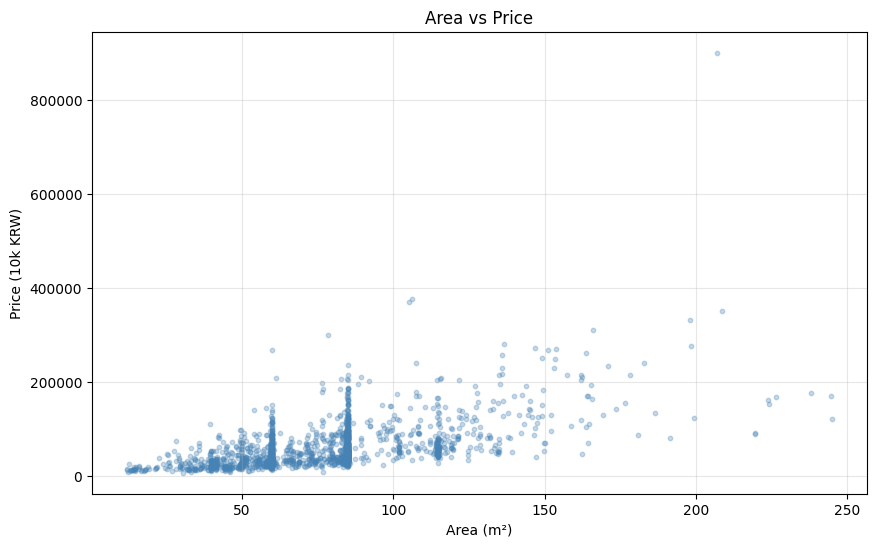

Correlation: 0.572


In [2]:
# Scatter plot of a small sample
sample = df.sample(n=2000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['area_m2'], sample['price_10k_krw'], alpha=0.3, s=10, c='steelblue')
plt.xlabel('Area (m²)')
plt.ylabel('Price (10k KRW)')
plt.title('Area vs Price')
plt.grid(True, alpha=0.3)
plt.show()

# Correlation
corr = df['area_m2'].corr(df['price_10k_krw'])
print(f"Correlation: {corr:.3f}")

### 3. Prepare Data for Training (Scaling)
**Crucial Step for SGD**: We *must* scale our data.
SGD is sensitive to the scale of features. If we don't scale `Area` (which is ~100) compared to `Price` (which is ~100,000), SGD will struggle to converge.

In [3]:
X = df['area_m2'].values.reshape(-1, 1)  # Feature
y = df['price_10k_krw'].values           # Target

# Split into Train (80%) and Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Data: {len(X_train):,} samples")
print(f"Original Mean Area: {X_train.mean():.1f} -> Scaled Mean: {X_train_scaled.mean():.1f}")

Training Data: 79,996 samples
Original Mean Area: 77.2 -> Scaled Mean: 0.0


### 4. Train the Model (SGD)
We use `SGDRegressor` instead of ordinary LinearRegression.
This simulates how deep learning models learn: iteratively reducing error.

In [4]:
# Using SGDRegressor
# max_iter: Maximum number of epochs (loops)
# eta0: Initial learning rate
model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
model.fit(X_train_scaled, y_train)

print("Training Complete! 🚀")
print(f"Learned Weight (scaled): {model.coef_[0]:.2f}")
print(f"Learned Bias: {model.intercept_[0]:.2f}")

Training Complete! 🚀
Learned Weight (scaled): 24905.57
Learned Bias: 58385.64


### 5. Evaluate Performance
How good is our model? We check the **RMSE** using the test set.

In [5]:
# Predict on Scaled Test Set
y_pred = model.predict(X_test_scaled)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:,.0f} (10k KRW)")

RMSE: 38,353 (10k KRW)


### 6. Visualizing the Result
Let's see the line our model learned.

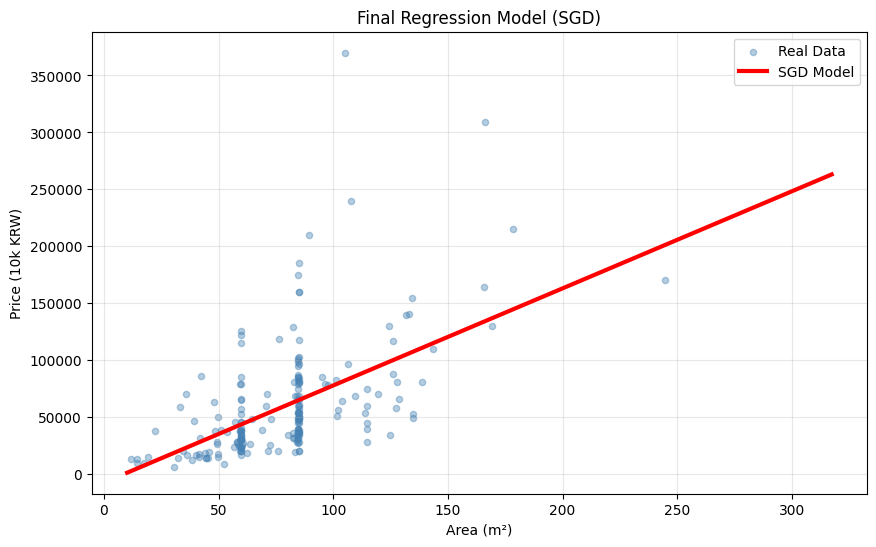

In [6]:
plt.figure(figsize=(10, 6))

# Scatter plot for data points (Sample)
plt.scatter(X_test[:200], y_test[:200], alpha=0.4, s=20, c='steelblue', label='Real Data')

# Line plot for model prediction
# We predict on a range of scaled X values
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)
y_range = model.predict(X_range_scaled)

plt.plot(X_range, y_range, 'r-', linewidth=3, label='SGD Model')

plt.xlabel('Area (m²)')
plt.ylabel('Price (10k KRW)')
plt.title('Final Regression Model (SGD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 7. Try a Prediction
Enter an area (e.g., 84 m2). **Remember to scale it first!**

In [7]:
area_input = 84

# Scale the input using the SAME scaler
input_scaled = scaler.transform([[area_input]])

predicted_price = model.predict(input_scaled)[0]

print(f"Predicted price for {area_input} m²: {predicted_price:,.0f} (10k KRW)")
print(f"In 억원: {predicted_price/10000:.2f} 억원")

Predicted price for 84 m²: 64,170 (10k KRW)
In 억원: 6.42 억원
